# Redes Neurais Convolucionais (CNN) com TensorFlow

---

- Entender o funcionamento de convoluções, pooling e mapas de características
- Construir CNNs progressivamente com a API Keras
- Aplicar Data Augmentation para generalização
- Visualizar filtros e ativações internas
- Treinar e avaliar um classificador no CIFAR-10

**Dataset:** CIFAR-10 (60.000 imagens 32×32 em 10 classes)  
**Framework:** TensorFlow 2.x + Keras  

---

## 0. Configuração do Ambiente

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import warnings
warnings.filterwarnings('ignore')

# Reprodutibilidade
tf.random.set_seed(42)
np.random.seed(42)

print(f"TensorFlow versão: {tf.__version__}")
print(f"GPUs disponíveis: {tf.config.list_physical_devices('GPU')}")

# Estilo de gráficos
plt.rcParams['figure.facecolor'] = '#0d0d14'
plt.rcParams['axes.facecolor']   = '#13131e'
plt.rcParams['axes.edgecolor']   = '#333355'
plt.rcParams['text.color']       = '#e8e8f0'
plt.rcParams['axes.labelcolor']  = '#8888aa'
plt.rcParams['xtick.color']      = '#8888aa'
plt.rcParams['ytick.color']      = '#8888aa'
plt.rcParams['grid.color']       = '#1a1a28'
plt.rcParams['figure.dpi']       = 120

TensorFlow versão: 2.21.0
GPUs disponíveis: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


---
## 1. Entendendo Convoluções

Uma **convolução 2D** aplica um filtro (kernel) sobre a imagem de forma deslizante.  
Cada posição gera um único valor: a soma elemento-a-elemento entre o filtro e o trecho da imagem.

```
Imagem (5×5)      Filtro (3×3)        Mapa de características (3×3)
┌─────────────┐   ┌─────────┐         ┌─────────┐
│ 1 1 1 0 0  │   │ 1  0 1 │         │ 4 3 4  │
│ 0 1 1 1 0  │ * │ 0  1 0 │    →    │ 2 4 3  │
│ 0 0 1 1 1  │   │ 1  0 1 │         │ 2 3 4  │
│ 0 0 1 1 0  │   └─────────┘         └─────────┘
│ 0 1 1 0 0  │
└─────────────┘
```

**Parâmetros importantes:**
- `filters`: número de filtros (profundidade do mapa de saída)
- `kernel_size`: tamanho do filtro (ex: 3×3)
- `padding='same'`: mantém dimensões; `'valid'`: reduz dimensões
- `strides`: de quanto o filtro desliza

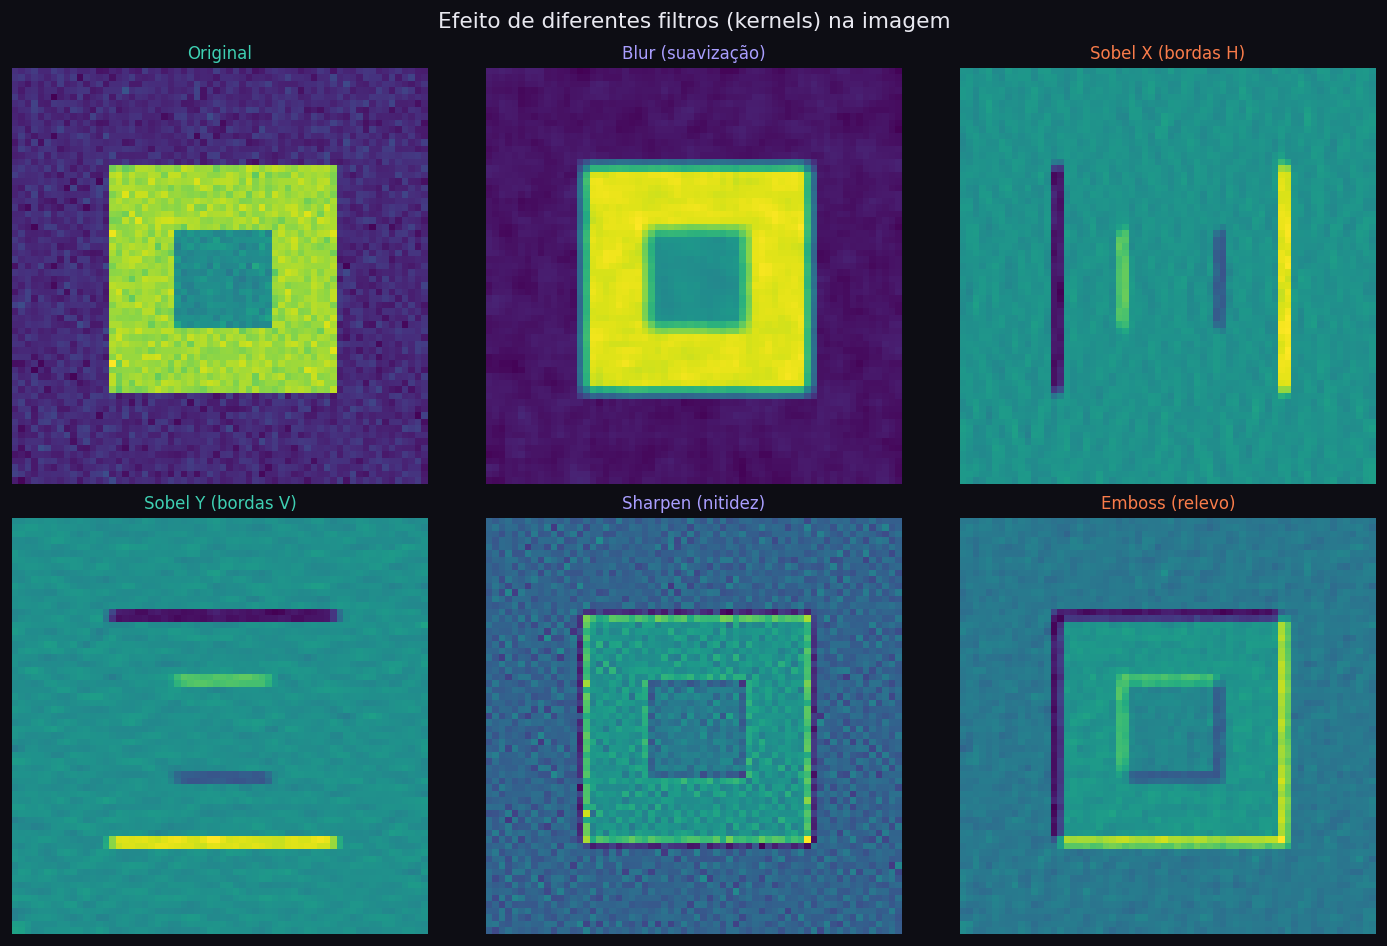

💡 Em uma CNN, esses filtros são APRENDIDOS automaticamente durante o treinamento!


In [7]:
# Demonstração: aplicar filtros clássicos de visão computacional manualmente
from scipy import ndimage
from PIL import Image

# Criar imagem de teste simples (gradiente + borda)
img_size = 64
img = np.zeros((img_size, img_size))
img[15:50, 15:50] = 1.0          # retângulo
img[25:40, 25:40] = 0.5          # retângulo interno
img += np.random.normal(0, 0.05, img.shape)  # ruído

# Filtros clássicos
filtros = {
    'Original': np.array([[0, 0, 0], [0, 1, 0], [0, 0, 0]]),
    'Blur (suavização)': np.ones((3, 3)) / 9,
    'Sobel X (bordas H)': np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]]),
    'Sobel Y (bordas V)': np.array([[-1,-2,-1], [0, 0, 0], [1, 2, 1]]),
    'Sharpen (nitidez)': np.array([[0,-1, 0], [-1, 5,-1], [0,-1, 0]]),
    'Emboss (relevo)': np.array([[-2,-1, 0], [-1, 1, 1], [0, 1, 2]]),
}

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
fig.suptitle('Efeito de diferentes filtros (kernels) na imagem', 
             fontsize=13, color='#e8e8f0')

cores = ['#3ecfb2', '#a99eff', '#f97c4a', '#3ecfb2', '#a99eff', '#f97c4a']

for ax, (nome, filtro), cor in zip(axes.flat, filtros.items(), cores):
    resultado = ndimage.convolve(img, filtro)
    ax.imshow(resultado, cmap='viridis', aspect='equal')
    ax.set_title(nome, color=cor, fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

print("💡 Em uma CNN, esses filtros são APRENDIDOS automaticamente durante o treinamento!")

---
## 2. Dataset CIFAR-10

**10 classes:** avião, automóvel, pássaro, gato, cervo, cachorro, sapo, cavalo, navio, caminhão  
**Tamanho:** 50.000 treino / 10.000 teste — imagens 32×32 RGB

In [8]:
# Carregar CIFAR-10
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

CLASSES = ['avião', 'automóvel', 'pássaro', 'gato', 'cervo',
           'cachorro', 'sapo', 'cavalo', 'navio', 'caminhão']

print(f"Treino:  {x_train.shape}  |  Labels: {y_train.shape}")
print(f"Teste:   {x_test.shape}   |  Labels: {y_test.shape}")
print(f"Valores dos pixels: [{x_train.min()}, {x_train.max()}]")
print(f"Classes: {CLASSES}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step
Treino:  (50000, 32, 32, 3)  |  Labels: (50000, 1)
Teste:   (10000, 32, 32, 3)   |  Labels: (10000, 1)
Valores dos pixels: [0, 255]
Classes: ['avião', 'automóvel', 'pássaro', 'gato', 'cervo', 'cachorro', 'sapo', 'cavalo', 'navio', 'caminhão']


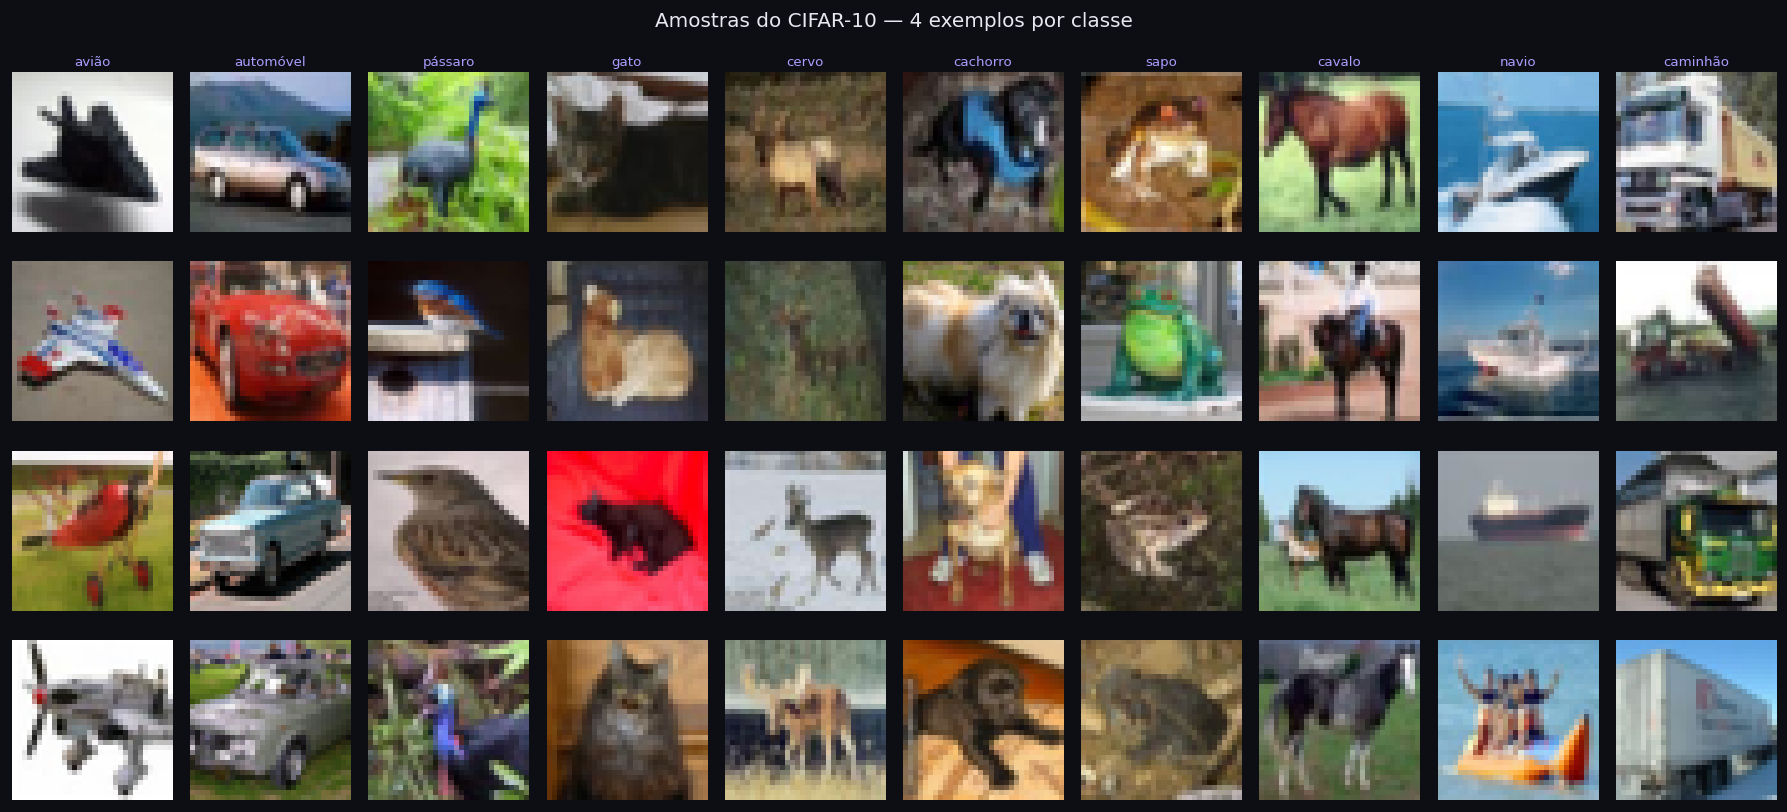

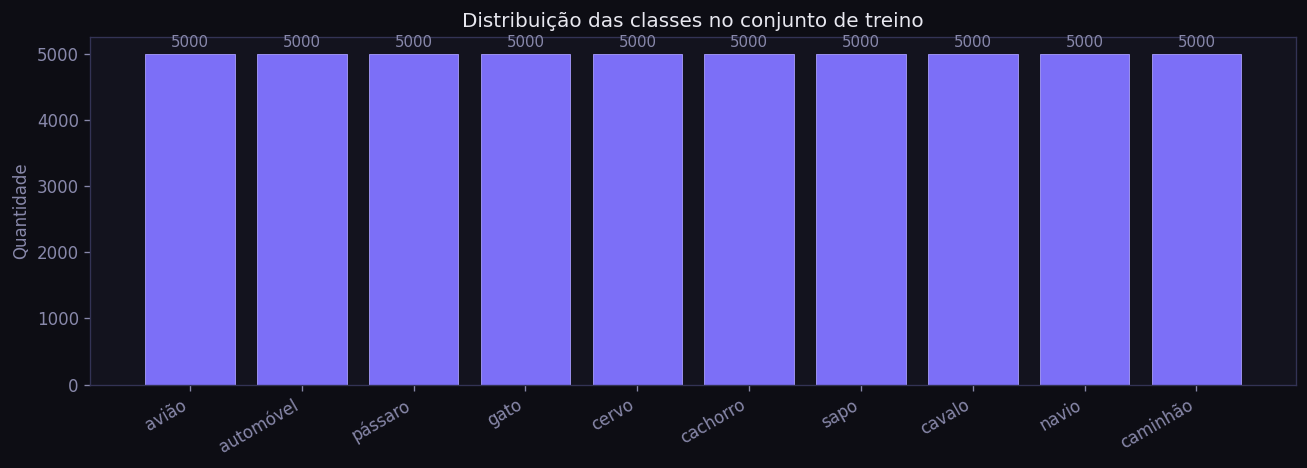

In [9]:
# Visualizar amostras do dataset
fig, axes = plt.subplots(4, 10, figsize=(15, 7))
fig.suptitle('Amostras do CIFAR-10 — 4 exemplos por classe', 
             color='#e8e8f0', fontsize=12)

for classe_idx in range(10):
    idxs = np.where(y_train.flatten() == classe_idx)[0][:4]
    for linha, idx in enumerate(idxs):
        ax = axes[linha, classe_idx]
        ax.imshow(x_train[idx])
        ax.axis('off')
        if linha == 0:
            ax.set_title(CLASSES[classe_idx], color='#a99eff', fontsize=8, pad=4)

plt.tight_layout()
plt.show()

# Distribuição das classes
fig, ax = plt.subplots(figsize=(11, 4))
unique, counts = np.unique(y_train, return_counts=True)
bars = ax.bar(CLASSES, counts, color='#7c6ff7', edgecolor='#a99eff', linewidth=0.5)
ax.set_title('Distribuição das classes no conjunto de treino', color='#e8e8f0')
ax.set_ylabel('Quantidade', color='#8888aa')
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            str(count), ha='center', va='bottom', color='#8888aa', fontsize=9)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

---
## 3. Pré-processamento e Data Augmentation

In [10]:
# Normalizar pixels para [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32') / 255.0

# Separar validação (10% do treino)
val_size = int(len(x_train) * 0.1)
x_val, y_val       = x_train[:val_size], y_train[:val_size]
x_train, y_train   = x_train[val_size:], y_train[val_size:]

print(f"Treino:     {x_train.shape[0]:,} imagens")
print(f"Validação:  {x_val.shape[0]:,} imagens")
print(f"Teste:      {x_test.shape[0]:,} imagens")
print(f"Shape de uma imagem: {x_train.shape[1:]}  (altura × largura × canais)")

Treino:     45,000 imagens
Validação:  5,000 imagens
Teste:      10,000 imagens
Shape de uma imagem: (32, 32, 3)  (altura × largura × canais)


I0000 00:00:1779323809.040539    7070 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5563 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


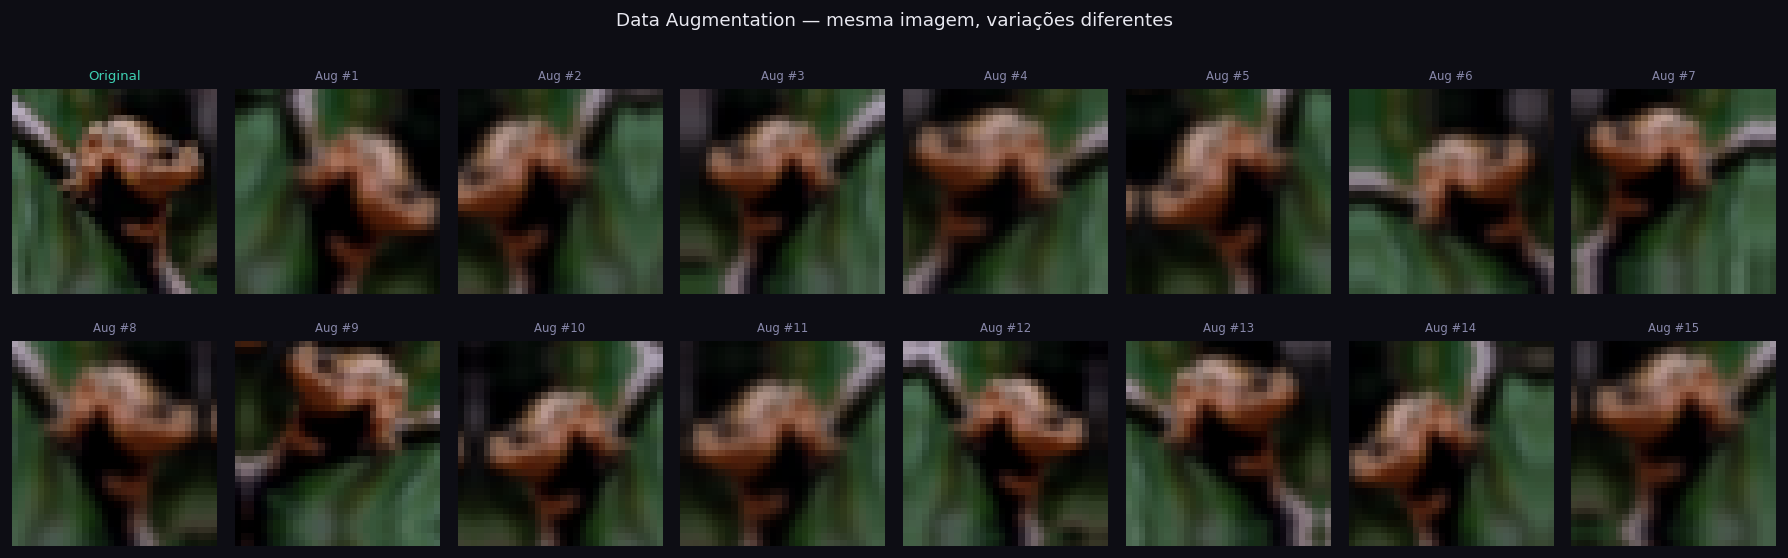

💡 A augmentation é aplicada aleatoriamente a cada batch durante o treino — o modelo nunca vê a mesma imagem duas vezes!


In [11]:
# Data Augmentation — camadas dentro do modelo (executam apenas no treinamento)
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),        # espelhar horizontalmente
    layers.RandomRotation(0.1),             # rotação até ±10%
    layers.RandomZoom(0.1),                 # zoom até 10%
    layers.RandomTranslation(0.1, 0.1),    # translação até 10%
    layers.RandomContrast(0.1),             # variação de contraste
], name='data_augmentation')

# Visualizar efeito da augmentation
sample = x_train[:1]  # pegar uma imagem

fig, axes = plt.subplots(2, 8, figsize=(15, 5))
fig.suptitle('Data Augmentation — mesma imagem, variações diferentes', 
             color='#e8e8f0', fontsize=11)

axes[0, 0].imshow(sample[0])
axes[0, 0].set_title('Original', color='#3ecfb2', fontsize=8)
axes[0, 0].axis('off')

for i, ax in enumerate(axes.flat):
    if i == 0:
        continue
    aug = data_augmentation(sample, training=True)[0]
    ax.imshow(np.clip(aug.numpy(), 0, 1))
    ax.set_title(f'Aug #{i}', color='#8888aa', fontsize=7)
    ax.axis('off')

plt.tight_layout()
plt.show()

print("💡 A augmentation é aplicada aleatoriamente a cada batch durante o treino — o modelo nunca vê a mesma imagem duas vezes!")

---
## 4. Construindo CNNs Progressivamente

Vamos construir **3 modelos** com complexidade crescente para observar a diferença de desempenho.

In [15]:
# ─── MODELO 1: CNN Simples ───────────────────────────────────────────────────

def criar_cnn_simples(num_classes=10):
    """CNN básica com 2 blocos convolucionais."""
    model = keras.Sequential([
        keras.Input(shape=(32, 32, 3)),
        
        # Bloco 1
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        
        # Bloco 2
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        
        # Classificador
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(num_classes, activation='softmax'),
    ], name='cnn_simples')
    return model

model1 = criar_cnn_simples()
model1.summary()
print(f"\nTotal de parâmetros treináveis: {model1.count_params():,}")

Model: "cnn_simples"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_22 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)


Total de parâmetros treináveis: 545,098


In [16]:
# ─── MODELO 2: CNN com BatchNorm e Dropout ───────────────────────────────────

def criar_cnn_regularizada(num_classes=10):
    """CNN com BatchNormalization e Dropout para melhor generalização."""
    model = keras.Sequential([
        keras.Input(shape=(32, 32, 3)),
        
        # Augmentation (só ativa no treino)
        data_augmentation,
        
        # Bloco 1
        layers.Conv2D(32, (3, 3), padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(32, (3, 3), padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Bloco 2
        layers.Conv2D(64, (3, 3), padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(64, (3, 3), padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Bloco 3
        layers.Conv2D(128, (3, 3), padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.5),
        
        # Classificador
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax'),
    ], name='cnn_regularizada')
    return model

model2 = criar_cnn_regularizada()
model2.summary()
print(f"\nTotal de parâmetros treináveis: {model2.count_params():,}")

Model: "cnn_regularizada"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 32, 32, 32)     │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_18 (Activation)      │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 32, 32, 32)     │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_19 (Activation)      │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 16, 16, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_20 (Activation)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 16, 16, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_21 (Activation)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 8, 8, 128)      │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_22 (Activation)      │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             

 Total params: 177,002 (691.41 KB)

 Trainable params: 175,850 (686.91 KB)

 Non-trainable params: 1,152 (4.50 KB)


Total de parâmetros treináveis: 177,002


In [17]:
# ─── MODELO 3: CNN com conexões residuais (estilo ResNet) ────────────────────

def bloco_residual(x, filters, stride=1):
    """Bloco residual: saída = F(x) + x"""
    shortcut = x
    
    # Caminho principal
    x = layers.Conv2D(filters, (3, 3), strides=stride, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    
    x = layers.Conv2D(filters, (3, 3), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    
    # Ajustar shortcut se necessário
    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, (1, 1), strides=stride, use_bias=False)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)
    
    # Conexão residual
    x = layers.Add()([x, shortcut])
    x = layers.Activation('relu')(x)
    return x

def criar_mini_resnet(num_classes=10):
    """Mini ResNet personalizada para CIFAR-10."""
    inputs = keras.Input(shape=(32, 32, 3))
    
    # Augmentation
    x = data_augmentation(inputs)
    
    # Stem
    x = layers.Conv2D(64, (3, 3), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    
    # Blocos residuais
    x = bloco_residual(x, 64)
    x = bloco_residual(x, 64)
    x = bloco_residual(x, 128, stride=2)
    x = bloco_residual(x, 128)
    x = bloco_residual(x, 256, stride=2)
    x = bloco_residual(x, 256)
    
    # Head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    return keras.Model(inputs, outputs, name='mini_resnet')

model3 = criar_mini_resnet()
model3.summary()
print(f"\nTotal de parâmetros treináveis: {model3.count_params():,}")

Model: "mini_resnet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 32, 32, 3) │          0 │ input_layer_6[0]… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_29 (Conv2D)  │ (None, 32, 32,    │      1,728 │ data_augmentatio… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_29[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_23       │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_30 (Conv2D)  │ (None, 32, 32,    │     36,864 │ activation_23[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_30[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_24       │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_31 (Conv2D)  │ (None, 32, 32,    │     36,864 │ activation_24[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_31[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_6 (Add)         │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ activation_23[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_25       │ (None, 32, 32,    │          0 │ add_6[0][0]       │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_32 (Conv2D)  │ (None, 32, 32,    │     36,864 │ activation_25[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_32[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_26       │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_33 (Conv2D)  │ (None, 32, 32,    │     36,864 │ activation_26[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_33[0][0] 

 Total params: 2,782,154 (10.61 MB)

 Trainable params: 2,777,674 (10.60 MB)

 Non-trainable params: 4,480 (17.50 KB)


Total de parâmetros treináveis: 2,782,154


---
## 5. Treinamento com Callbacks

Treinaremos o **Modelo 2 (CNN Regularizada)** — bom equilíbrio entre velocidade e desempenho.

In [18]:
# Compilar modelo
model1.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks
callbacks = [
    # Salvar o melhor modelo
    keras.callbacks.ModelCheckpoint(
        'melhor_modelo_cnn.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    # Parar cedo se não melhorar
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),
    # Reduzir LR quando estagnar
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=4,
        min_lr=1e-6,
        verbose=1
    ),
]

print("Modelo compilado. Pronto para treinar!")

Modelo compilado. Pronto para treinar!


In [20]:
# ⚠️ Dica: reduza EPOCHS para um teste rápido (ex: 5)
EPOCHS = 30
BATCH_SIZE = 64

history = model1.fit(
    x_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(x_val, y_val),
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
698/704 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7532 - loss: 0.7194
Epoch 1: val_accuracy did not improve from 0.69840
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7573 - loss: 0.7058 - val_accuracy: 0.6976 - val_loss: 0.8619 - learning_rate: 0.0010
Epoch 2/30
697/704 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7764 - loss: 0.6515
Epoch 2: val_accuracy did not improve from 0.69840
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7809 - loss: 0.6404 - val_accuracy: 0.6972 - val_loss: 0.8778 - learning_rate: 0.0010
Epoch 3/30
697/704 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7966 - loss: 0.5900
Epoch 3: val_accuracy did not improve from 0.69840
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8018 - loss: 0.5795 - val_accuracy: 0.6982 - val_loss: 0.9052 - learning_rate: 0.0010
Epoch 4/30
694/704 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8145 - loss: 0.5363
Epoch 4: val_accuracy improved from 0.69840 to 0.70200, saving model to melhor_m

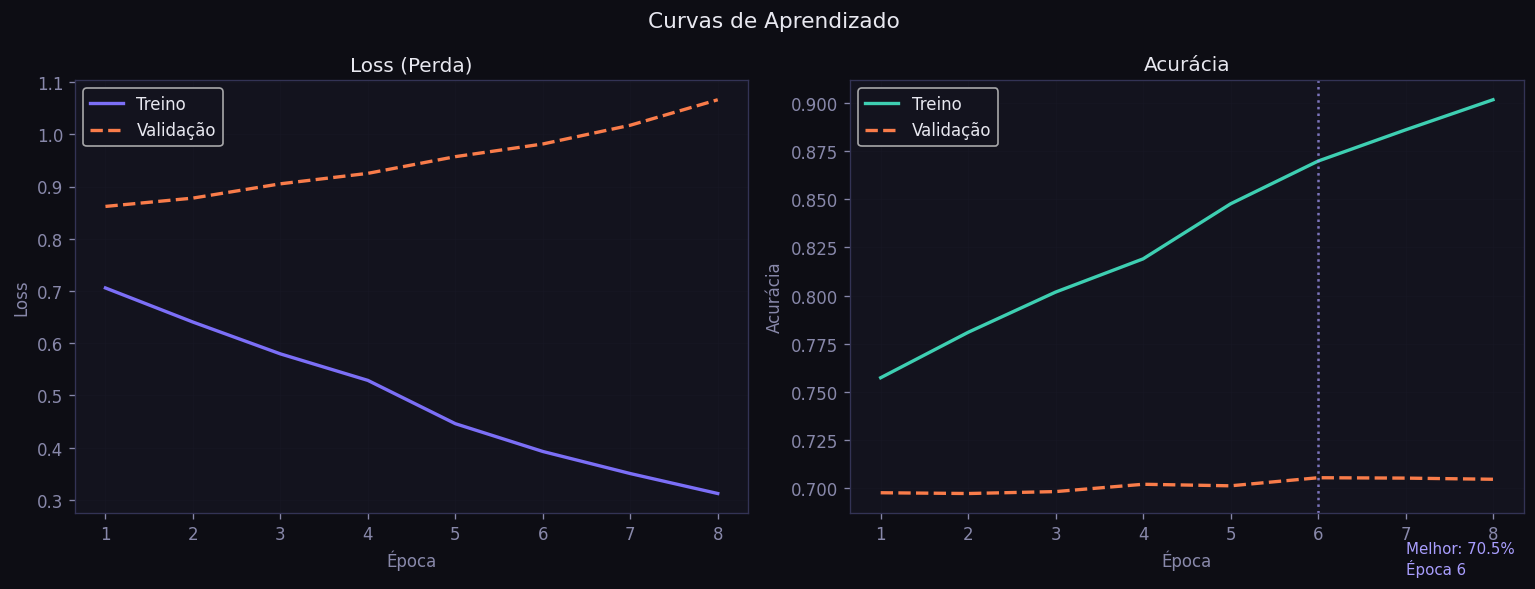

In [22]:
# Visualizar curvas de aprendizado
def plotar_historico(history):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle('Curvas de Aprendizado', color='#e8e8f0', fontsize=13)
    
    epocas = range(1, len(history.history['loss']) + 1)
    
    # Loss
    axes[0].plot(epocas, history.history['loss'],     color='#7c6ff7', lw=2, label='Treino')
    axes[0].plot(epocas, history.history['val_loss'], color='#f97c4a', lw=2, linestyle='--', label='Validação')
    axes[0].set_title('Loss (Perda)', color='#e8e8f0')
    axes[0].set_xlabel('Época')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Accuracy
    axes[1].plot(epocas, history.history['accuracy'],     color='#3ecfb2', lw=2, label='Treino')
    axes[1].plot(epocas, history.history['val_accuracy'], color='#f97c4a', lw=2, linestyle='--', label='Validação')
    axes[1].set_title('Acurácia', color='#e8e8f0')
    axes[1].set_xlabel('Época')
    axes[1].set_ylabel('Acurácia')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    # Melhor época
    best_epoch = np.argmax(history.history['val_accuracy']) + 1
    best_acc = max(history.history['val_accuracy'])
    axes[1].axvline(best_epoch, color='#a99eff', linestyle=':', alpha=0.7)
    axes[1].annotate(f'Melhor: {best_acc:.1%}\nÉpoca {best_epoch}',
                     xy=(best_epoch, best_acc),
                     xytext=(best_epoch + 1, best_acc - 0.05),
                     color='#a99eff', fontsize=9)
    
    plt.tight_layout()
    plt.show()

plotar_historico(history)

---
## 6. Avaliação e Matriz de Confusão

In [26]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Avaliar no conjunto de teste
loss, acc = model1.evaluate(x_test, y_test, verbose=0)
print(f"\n{'='*45}")
print(f"  Loss no teste:     {loss:.4f}")
print(f"  Acurácia no teste: {acc:.2%}")
print(f"{'='*45}")

# Predições
y_pred_proba = model2.predict(x_test, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = y_test.flatten()

# Relatório por classe
print("\nRelatório de classificação por classe:")
print(classification_report(y_true, y_pred, target_names=CLASSES))


  Loss no teste:     0.8915
  Acurácia no teste: 69.82%

Relatório de classificação por classe:
              precision    recall  f1-score   support

       avião       0.00      0.00      0.00      1000
   automóvel       0.00      0.00      0.00      1000
     pássaro       0.00      0.00      0.00      1000
        gato       0.00      0.00      0.00      1000
       cervo       0.10      0.85      0.18      1000
    cachorro       0.00      0.00      0.00      1000
        sapo       0.00      0.00      0.00      1000
      cavalo       0.00      0.00      0.00      1000
       navio       0.18      0.25      0.21      1000
    caminhão       0.06      0.00      0.00      1000

    accuracy                           0.11     10000
   macro avg       0.03      0.11      0.04     10000
weighted avg       0.03      0.11      0.04     10000



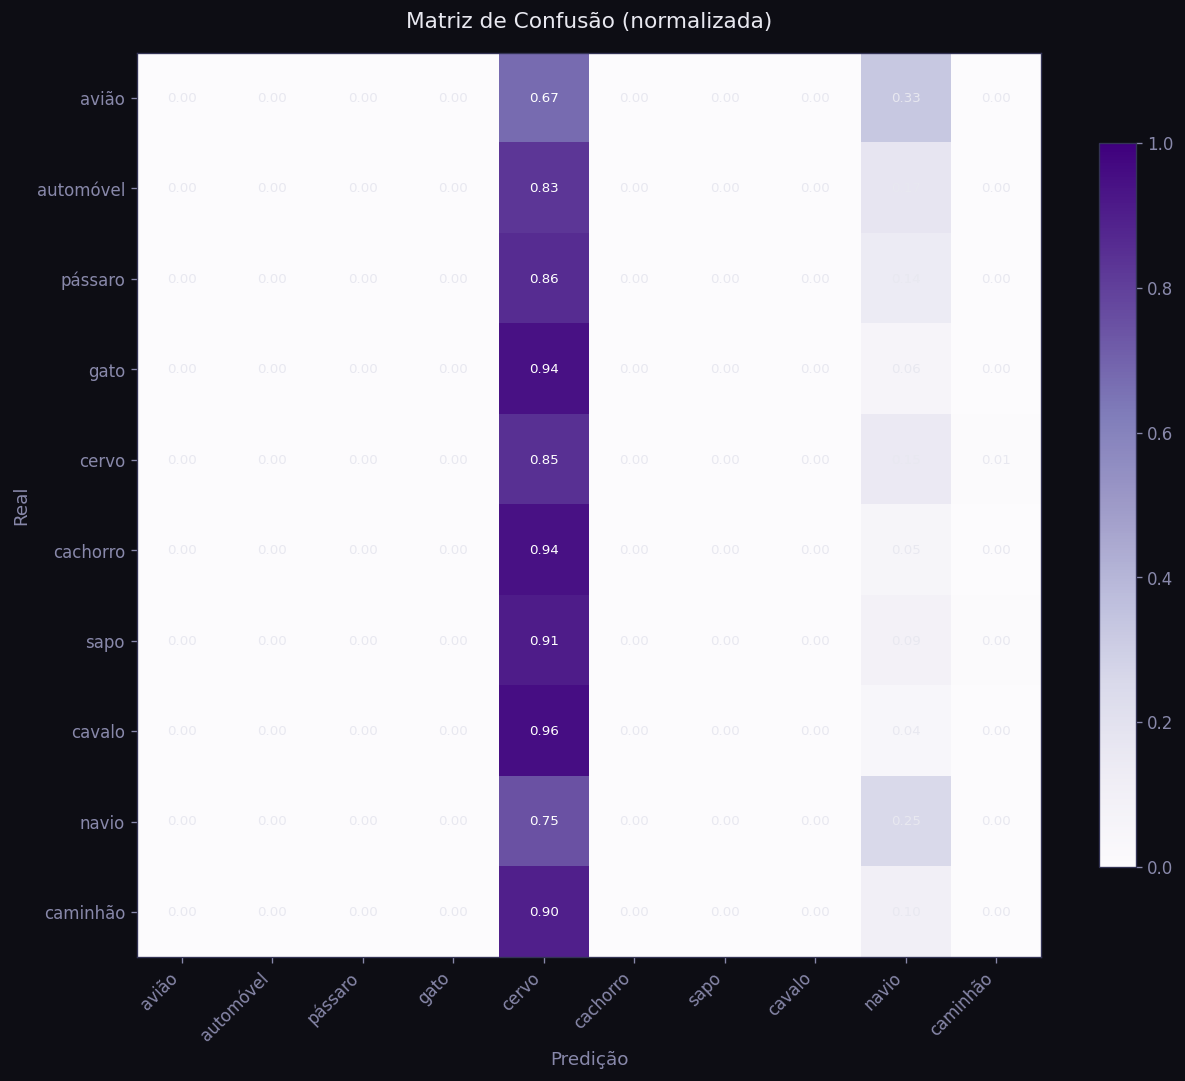


Pares mais confundidos (Real → Predito):
  cavalo       → cervo       : 956 erros
  cachorro     → cervo       : 944 erros
  gato         → cervo       : 942 erros
  sapo         → cervo       : 908 erros
  caminhão     → cervo       : 895 erros


In [29]:
# Matriz de Confusão
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]  # normalizar

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(cm_norm, cmap='Purples', vmin=0, vmax=1)

ax.set_xticks(range(10))
ax.set_yticks(range(10))
ax.set_xticklabels(CLASSES, rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(CLASSES, fontsize=10)
ax.set_xlabel('Predição', fontsize=11)
ax.set_ylabel('Real', fontsize=11)
ax.set_title('Matriz de Confusão (normalizada)', color='#e8e8f0', fontsize=13, pad=15)

for i in range(10):
    for j in range(10):
        cor = 'white' if cm_norm[i, j] > 0.5 else '#e8e8f0'
        ax.text(j, i, f'{cm_norm[i,j]:.2f}', ha='center', va='center',
                color=cor, fontsize=8)

plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

# Classes mais confundidas
print("\nPares mais confundidos (Real → Predito):")
np.fill_diagonal(cm, 0)
flat = cm.flatten()
top_idx = flat.argsort()[-5:][::-1]
for idx in top_idx:
    i, j = divmod(idx, 10)
    print(f"  {CLASSES[i]:12s} → {CLASSES[j]:12s}: {cm[i,j]} erros")

---
## 7. Visualizando o Interior da CNN

Uma das melhores formas de entender CNNs é visualizar o que cada camada aprende.

In [32]:
# Visualizar mapas de características (feature maps) de uma imagem

# Pegar nomes das camadas convolucionais
conv_layers = [l for l in model2.layers if isinstance(l, layers.Conv2D)]
print(f"Camadas convolucionais no modelo: {len(conv_layers)}")
for l in conv_layers:
    print(f"  {l.name:30s} — output shape: {l.output}")

# Modelo que retorna ativações de todas as camadas Conv2D
layer_outputs = [l.output for l in conv_layers[:3]]  # primeiras 3
activation_model = keras.Model(inputs=model2.inputs, outputs=layer_outputs)

Camadas convolucionais no modelo: 5
  conv2d_24                      — output shape: <KerasTensor shape=(None, 32, 32, 32), dtype=float32, sparse=False, ragged=False, name=keras_tensor_117>
  conv2d_25                      — output shape: <KerasTensor shape=(None, 32, 32, 32), dtype=float32, sparse=False, ragged=False, name=keras_tensor_120>
  conv2d_26                      — output shape: <KerasTensor shape=(None, 16, 16, 64), dtype=float32, sparse=False, ragged=False, name=keras_tensor_125>
  conv2d_27                      — output shape: <KerasTensor shape=(None, 16, 16, 64), dtype=float32, sparse=False, ragged=False, name=keras_tensor_128>
  conv2d_28                      — output shape: <KerasTensor shape=(None, 8, 8, 128), dtype=float32, sparse=False, ragged=False, name=keras_tensor_133>


Imagem: cachorro
Predição: cervo


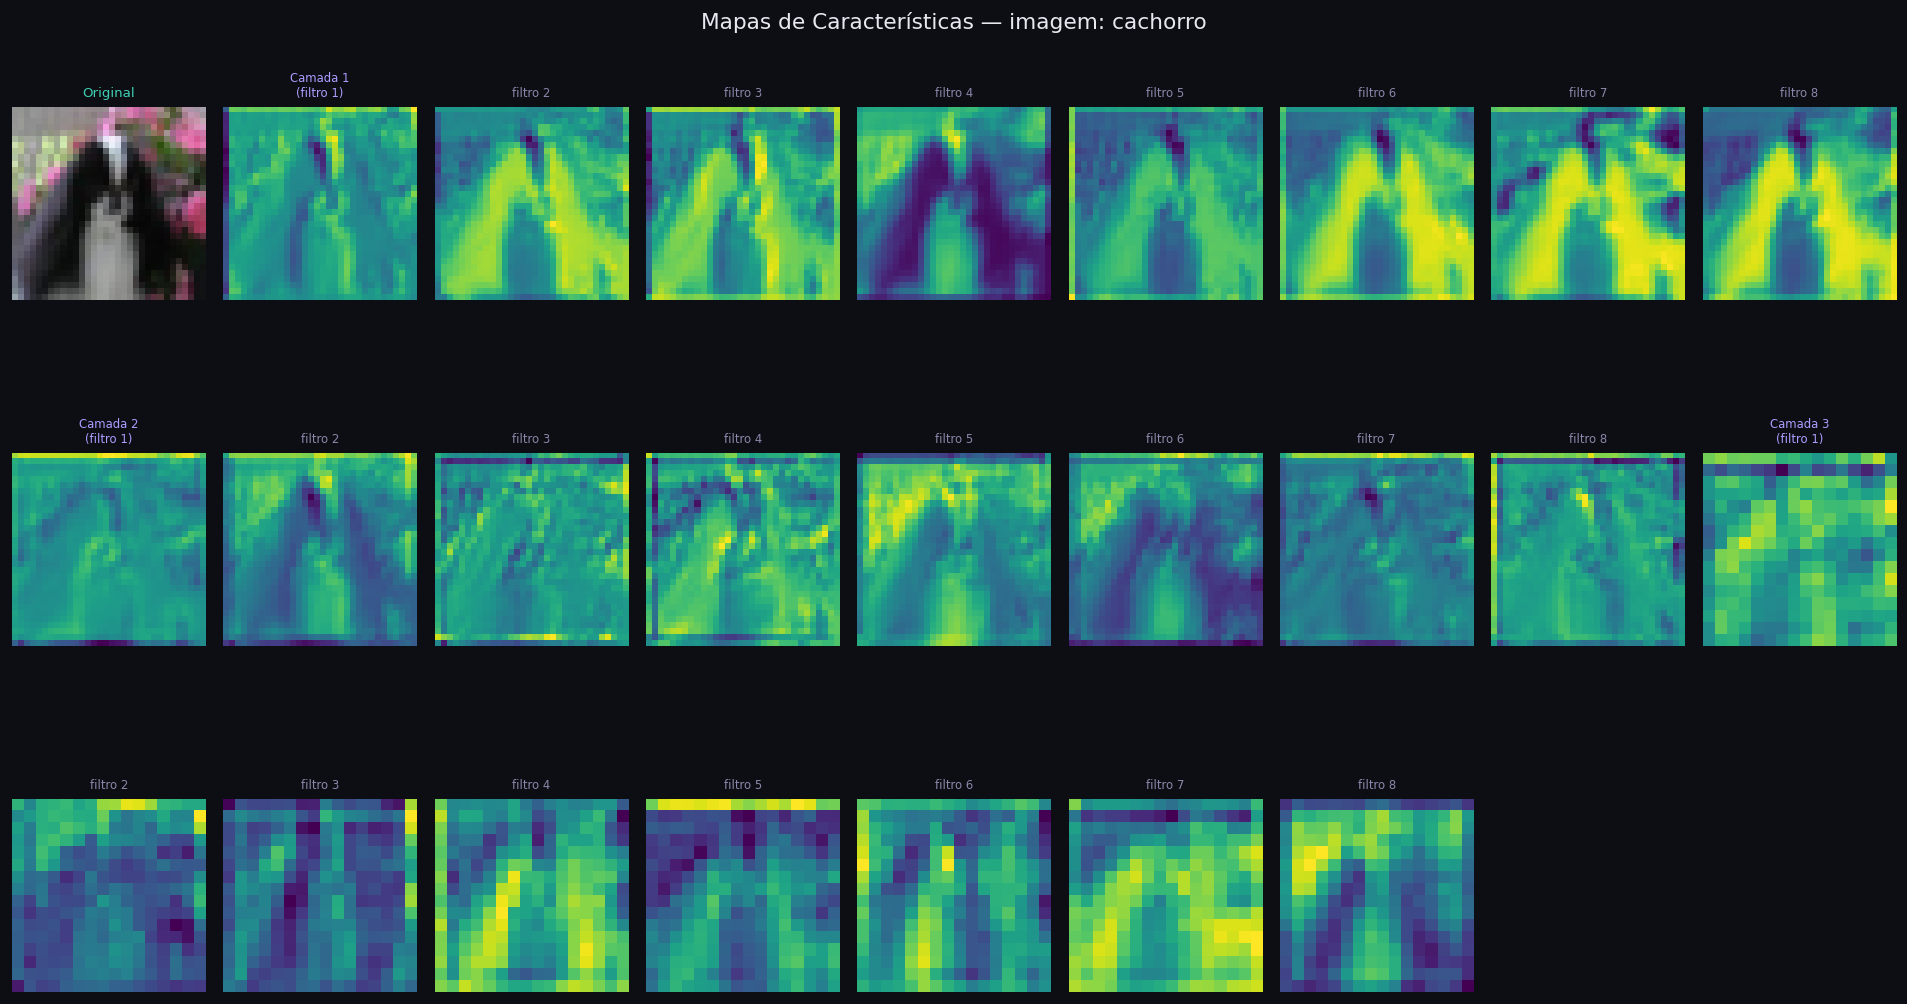


💡 Observe como as primeiras camadas detectam bordas e texturas simples,
   enquanto as camadas mais profundas detectam padrões mais complexos e abstratos.


In [36]:
# Escolher uma imagem de teste
idx_img = 42  # mude para explorar diferentes imagens
img_input = x_test[idx_img:idx_img+1]

print(f"Imagem: {CLASSES[y_test[idx_img][0]]}")
print(f"Predição: {CLASSES[np.argmax(model2.predict(img_input, verbose=0))]}")

# Obter ativações
activations = activation_model.predict(img_input, verbose=0)

# Visualizar
fig = plt.figure(figsize=(16, 12))
fig.suptitle(f'Mapas de Características — imagem: {CLASSES[y_test[idx_img][0]]}',
             color='#e8e8f0', fontsize=13)

# Mostrar imagem original
ax0 = fig.add_subplot(4, 9, 1)
ax0.imshow(img_input[0])
ax0.set_title('Original', color='#3ecfb2', fontsize=8)
ax0.axis('off')

# Mostrar primeiros 8 filtros das 3 primeiras camadas convolucionais
posicao = 2
for layer_idx, (activation, conv_layer) in enumerate(zip(activations, conv_layers[:3])):
    n_filtros = min(8, activation.shape[-1])
    for f in range(n_filtros):
        ax = fig.add_subplot(4, 9, posicao)
        fmap = activation[0, :, :, f]
        ax.imshow(fmap, cmap='viridis', aspect='equal')
        if f == 0:
            ax.set_title(f'Camada {layer_idx+1}\n(filtro {f+1})',
                         color='#a99eff', fontsize=7)
        else:
            ax.set_title(f'filtro {f+1}', color='#8888aa', fontsize=7)
        ax.axis('off')
        posicao += 1

plt.tight_layout()
plt.show()

print("\n💡 Observe como as primeiras camadas detectam bordas e texturas simples,")
print("   enquanto as camadas mais profundas detectam padrões mais complexos e abstratos.")

Erro no Grad-CAM: name 'model' is not defined
Erro no Grad-CAM: name 'model' is not defined
Erro no Grad-CAM: name 'model' is not defined
Erro no Grad-CAM: name 'model' is not defined
Erro no Grad-CAM: name 'model' is not defined
Erro no Grad-CAM: name 'model' is not defined


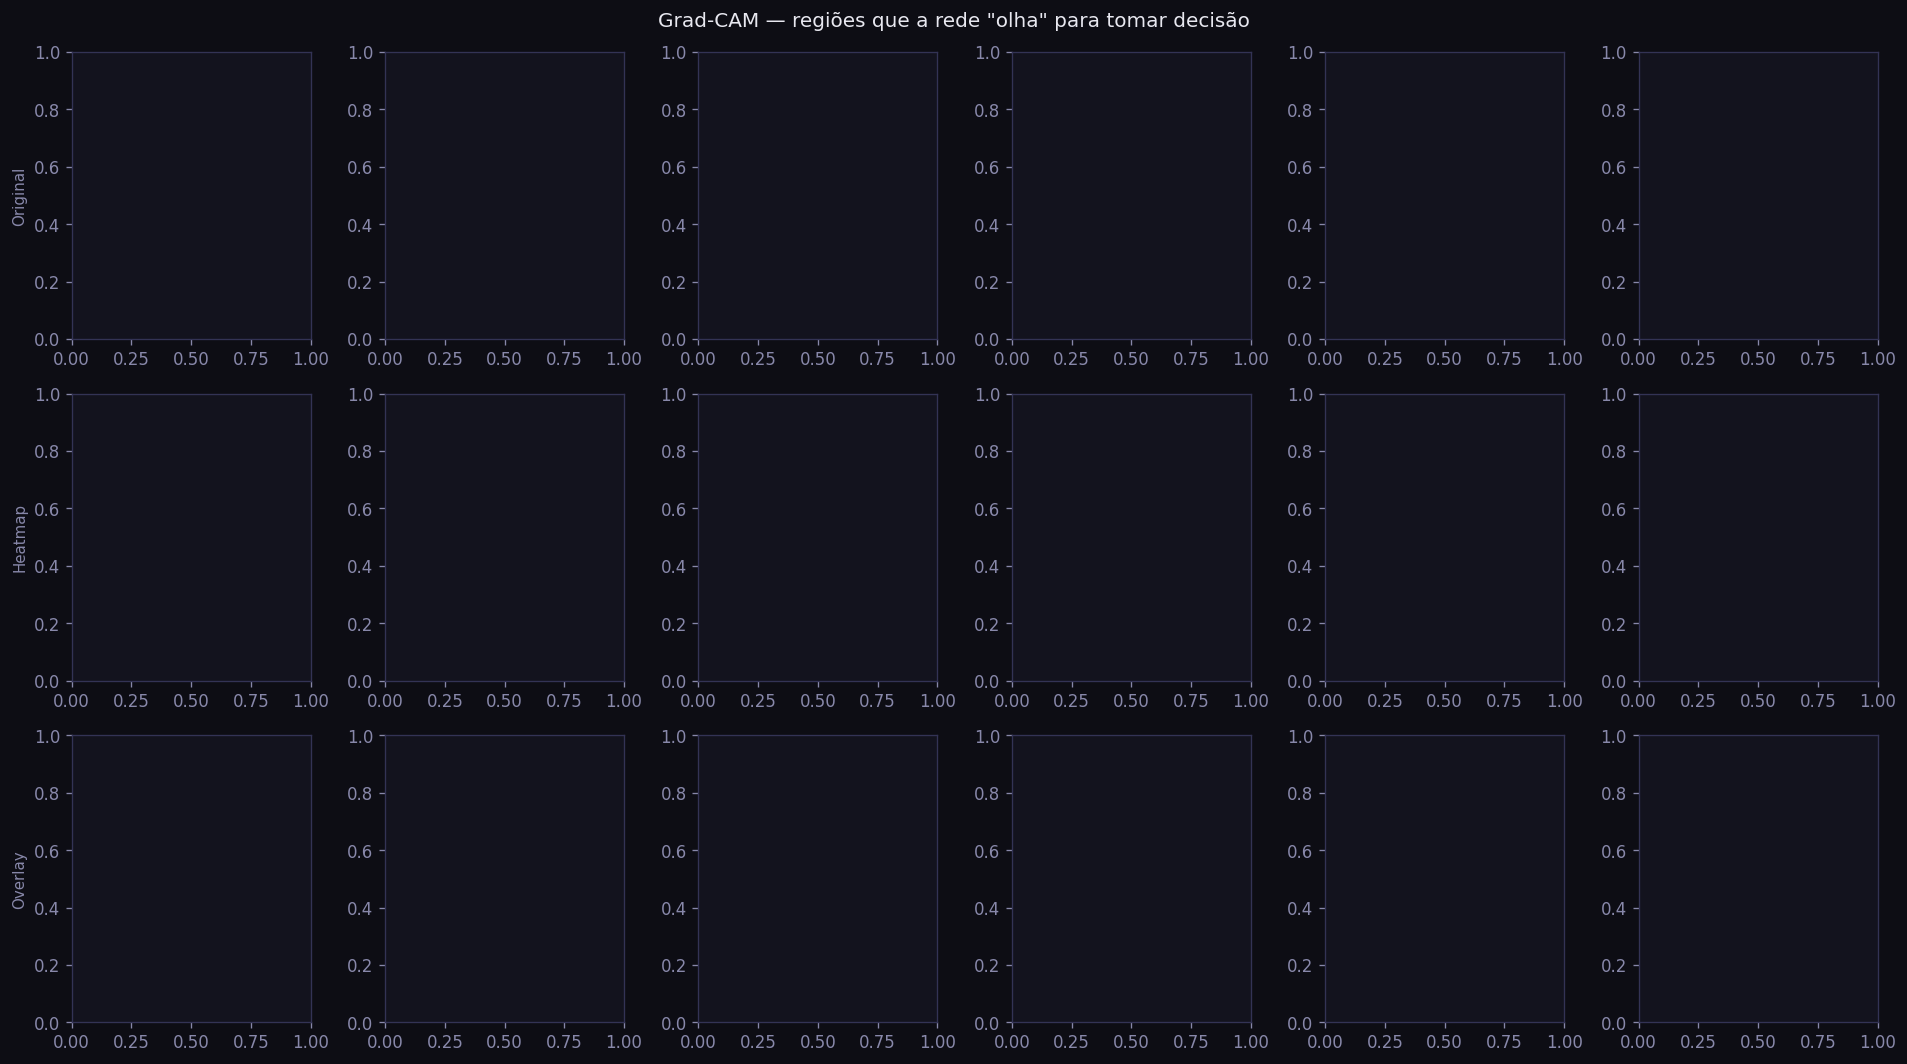

In [49]:
# Grad-CAM — destacar as regiões da imagem mais importantes para a predição

def grad_cam(model1, img_array, layer_name=None):
    """Implementação simplificada de Grad-CAM."""
    # Pegar a última camada convolucional
    if layer_name is None:
        for layer in reversed(model1.layers):
            if isinstance(layer, layers.Conv2D):
                layer_name = layer.name
                break
    
    grad_model = keras.Model(
        inputs=model.inputs,
        outputs=[model1.get_layer(layer_name).output, model1.output]
    )
    
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        pred_idx = tf.argmax(predictions[0])
        loss = predictions[:, pred_idx]
    
    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    
    return heatmap.numpy(), pred_idx.numpy(), float(tf.reduce_max(predictions))


# Visualizar Grad-CAM em 6 imagens
fig, axes = plt.subplots(3, 6, figsize=(16, 9))
fig.suptitle('Grad-CAM — regiões que a rede "olha" para tomar decisão',
             color='#e8e8f0', fontsize=12)

indices = np.random.choice(len(x_test), 6, replace=False)

for col, idx in enumerate(indices):
    img = x_test[idx:idx+1]
    real = CLASSES[y_test[idx][0]]
    
    try:
        heatmap, pred_idx, confianca = grad_cam(model1, img)
        pred = CLASSES[pred_idx]
        
        # Redimensionar heatmap
        from PIL import Image as PILImage
        heatmap_img = PILImage.fromarray((heatmap * 255).astype('uint8')).resize((32, 32))
        heatmap_arr = np.array(heatmap_img) / 255.0
        
        # Imagem original
        axes[0, col].imshow(img[0])
        cor = '#3ecfb2' if pred == real else '#f97c4a'
        axes[0, col].set_title(f'Real: {real}', color='#8888aa', fontsize=8)
        axes[0, col].axis('off')
        
        # Heatmap
        axes[1, col].imshow(heatmap_arr, cmap='jet')
        axes[1, col].set_title(f'Pred: {pred}', color=cor, fontsize=8)
        axes[1, col].axis('off')
        
        # Sobreposição
        overlay = img[0].copy()
        heatmap_rgb = plt.cm.jet(heatmap_arr)[:, :, :3]
        blend = 0.6 * overlay + 0.4 * heatmap_rgb
        axes[2, col].imshow(np.clip(blend, 0, 1))
        axes[2, col].set_title(f'{confianca:.0%}', color='#a99eff', fontsize=8)
        axes[2, col].axis('off')
    except Exception as e:
        print(f"Erro no Grad-CAM: {e}")

axes[0, 0].set_ylabel('Original', color='#8888aa', fontsize=9)
axes[1, 0].set_ylabel('Heatmap', color='#8888aa', fontsize=9)
axes[2, 0].set_ylabel('Overlay', color='#8888aa', fontsize=9)

plt.tight_layout()
plt.show()

---
## 8. Exercícios Práticos

### 🟢 Nível 1 — Básico

1. **Adicionar uma camada:** Adicione um 4º bloco convolucional com 256 filtros ao `model2`. Compare os resultados.
2. **Trocar ativação:** Substitua todas as ativações `'relu'` por `'elu'` e observe o impacto.
3. **Explorar batch size:** Treine com batch sizes de 32, 64 e 128. Qual converge mais rápido?

### 🟡 Nível 2 — Intermediário

4. **Comparar modelos:** Treine os 3 modelos (simples, regularizado, mini-ResNet) e plote a acurácia de validação comparativa em um único gráfico.
5. **Separable Convolutions:** Substitua as `Conv2D` por `SeparableConv2D`. Quantos parâmetros economizou? A acurácia mudou?
6. **Augmentation agressiva:** Adicione `RandomBrightness`, `RandomSaturation` e `GaussianNoise` ao pipeline. O modelo melhora?

### 🔴 Nível 3 — Avançado

7. **Dataset customizado:** Baixe um dataset do Kaggle (ex: Cats vs Dogs) e adapte o pipeline `image_dataset_from_directory`.
8. **Squeeze-and-Excitation:** Implemente um bloco SE (canal attention) e integre ao bloco residual.
9. **Visualização de filtros:** Gere a imagem que maximiza a ativação de cada filtro da primeira camada usando gradient ascent.

In [50]:
# ─── Exercício 4: Comparação entre os 3 modelos ──────────────────────────────
# Espaço para o aluno implementar

# Dica: compile e treine cada modelo com poucas épocas (5-10)
# e armazene os históricos para comparar

# histories = {}

# for nome, model in [('Simples', model1), ('Regularizado', model2), ('Mini-ResNet', model3)]:
#     model.compile(optimizer='adam',
#                   loss='sparse_categorical_crossentropy',
#                   metrics=['accuracy'])
#     hist = model.fit(x_train, y_train,
#                      epochs=10,
#                      batch_size=64,
#                      validation_data=(x_val, y_val),
#                      verbose=0)
#     histories[nome] = hist

print("Implemente a comparação entre os modelos aqui!")

Implemente a comparação entre os modelos aqui!


In [51]:
# ─── Exercício 8: Bloco Squeeze-and-Excitation ────────────────────────────────
# Dica de implementação

def squeeze_excitation(x, reduction_ratio=16):
    """Channel attention: aprende a importância de cada canal."""
    filters = x.shape[-1]
    
    # Squeeze: comprime informação espacial por canal
    se = layers.GlobalAveragePooling2D()(x)  # (batch, filters)
    
    # Excitation: aprende importância de cada canal
    se = layers.Dense(filters // reduction_ratio, activation='relu')(se)
    se = layers.Dense(filters, activation='sigmoid')(se)
    
    # Reshape para multiplicação
    se = layers.Reshape((1, 1, filters))(se)
    
    # Re-calibrar canais
    return layers.Multiply()([x, se])

# Teste o bloco:
test_input = keras.Input(shape=(16, 16, 64))
test_output = squeeze_excitation(test_input)
se_model = keras.Model(test_input, test_output)
print(f"Bloco SE: {test_input.shape} → {test_output.shape}")
print("Agora integre este bloco ao bloco_residual!")

Bloco SE: (None, 16, 16, 64) → (None, 16, 16, 64)
Agora integre este bloco ao bloco_residual!


---
## 9. Resumo e Próximos Passos

### O que aprendemos neste módulo:

| Conceito | O que é | Para que serve |
|---|---|---|
| Convolução 2D | Filtro deslizante sobre a imagem | Detectar padrões locais |
| MaxPooling | Redução espacial pelo máximo | Invariância e compressão |
| BatchNorm | Normaliza ativações por batch | Treinamento mais estável |
| Dropout | Desativa neurônios aleatoriamente | Regularização |
| Data Augmentation | Variações artificiais dos dados | Mais generalização |
| Conexão Residual | Atalho F(x) + x | Treinar redes muito profundas |
| Grad-CAM | Mapa de calor das ativações | Explicabilidade |

### Próximos passos sugeridos:
- **Módulo 7:** Transfer Learning — use EfficientNet/ResNet pré-treinados no ImageNet
- **Kaggle:** [Image Classification competitions](https://www.kaggle.com/competitions)
- **Papers:** LeNet, AlexNet, VGG, ResNet, EfficientNet — leia na ordem histórica
- **Prática:** Treine com seu próprio dataset usando `image_dataset_from_directory`

---
*Material didático — Deep Learning com TensorFlow | Módulo 4: CNN*